In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from kneed import KneeLocator
import umap
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from matplotlib.colors import ListedColormap

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

os.makedirs('cluster_output', exist_ok=True)

In [ ]:
# Load Data
df = pd.read_csv("../data_bps_datmin.csv")
print("Dataset Loaded!")

Dataset Loaded!


# EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 18 columns):
 #   Column                                                                  Non-Null Count  Dtype  
---  ------                                                                  --------------  -----  
 0   PROVINSI                                                                151 non-null    object 
 1   TAHUN                                                                   151 non-null    int64  
 2   APS 13-15                                                               151 non-null    float64
 3   APS 16-18                                                               151 non-null    float64
 4   APS 19-24                                                               151 non-null    float64
 5   TPT - Februari                                                          151 non-null    float64
 6   TPT - Agustus                                                           151 non-nu

In [ ]:
df.head()

,PROVINSI,TAHUN,APS 13-15,APS 16-18,APS 19-24,TPT - Februari,TPT - Agustus,TPAK - Februari,TPAK - Agustus,Garis Kemiskinan - Maret (Rp),Garis Kemiskinan - September (Rp),Jumlah Penduduk Miskin - Maret (ribu),Jumlah Penduduk Miskin - September (ribu),Persentase Penduduk Miskin - Maret,Persentase Penduduk Miskin - September,Indeks Pembangunan Manusia,Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi,Harapan Lama Sekolah (Tahun)
0,SUMATERA UTARA,2021,96.99,78.66,27.05,6.01,6.33,69.39,69.10,525756,648336,1343.86,1110.92,9.01,7.19,73.84,9.88,13.27
1,SUMATERA BARAT,2021,96.63,84.07,36.41,6.67,6.52,68.41,67.72,568703,714991,370.67,315.43,6.63,5.42,74.56,9.46,14.09
2,RIAU,2021,95.66,77.81,28.79,4.96,4.42,65.81,65.03,565937,702620,500.81,473.04,7.12,6.36,73.89,9.52,13.28
3,JAMBI,2021,96.39,72.50,24.14,4.76,5.09,67.30,67.17,506355,658100,293.86,272.70,8.09,7.26,72.62,9.03,13.04
4,SUMATERA SELATAN,2021,94.85,71.53,18.81,5.17,4.98,69.95,68.77,457455,564462,1113.76,948.84,12.84,10.51,71.83,8.78,12.54


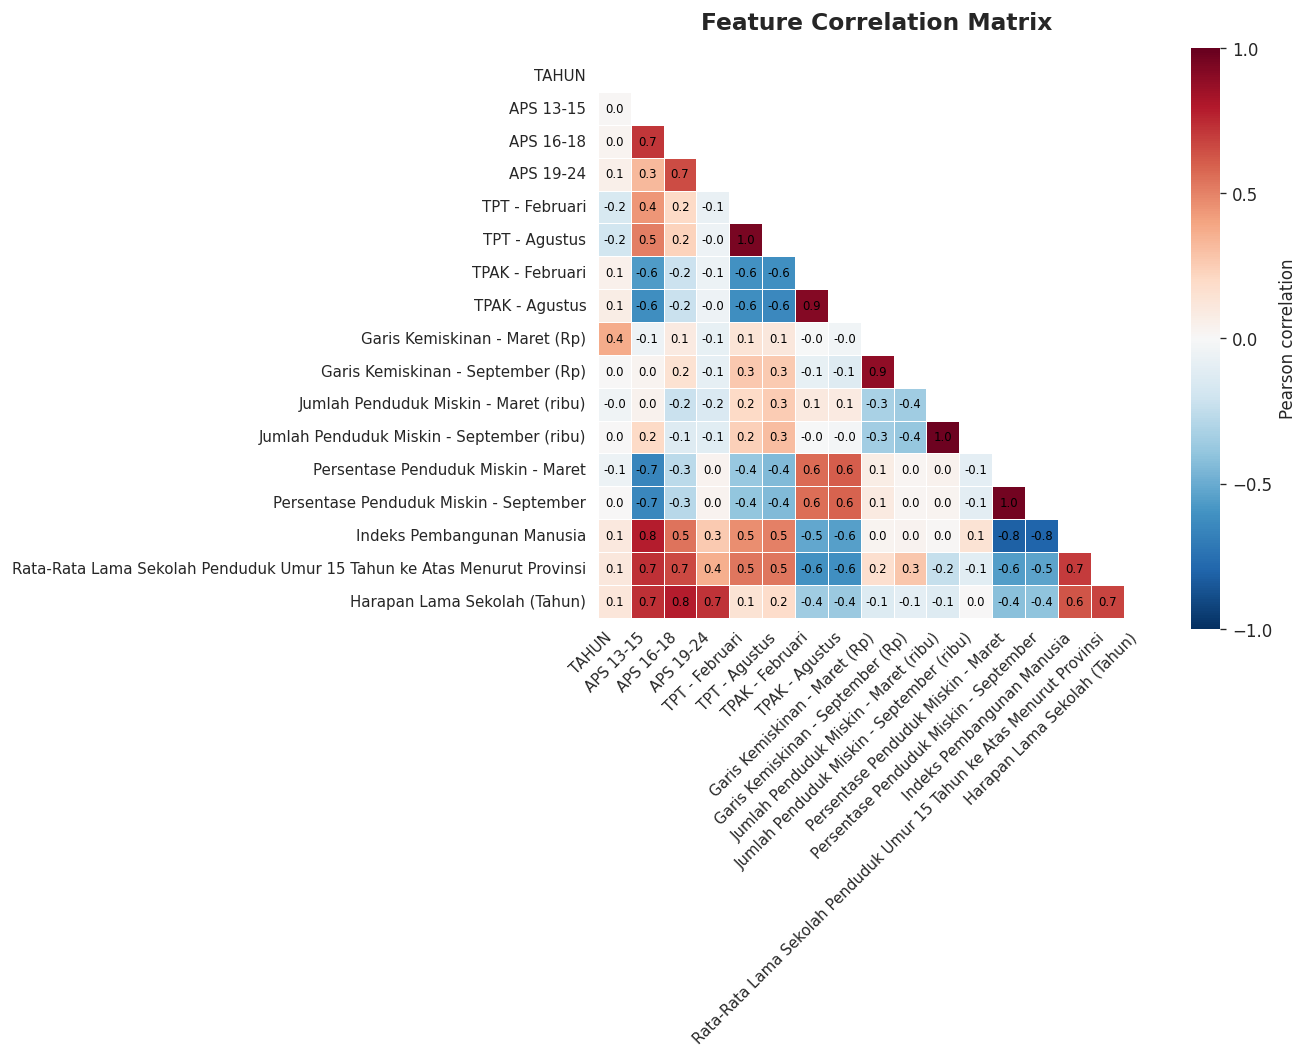

In [ ]:
cols = df.select_dtypes(include=['number']).columns
corr = df[cols].corr()

fig_corr = px.imshow(corr, text_auto=".1f", aspect="auto", color_continuous_scale="RdBu_r", zmin=-1, zmax=1)
fig_corr.update_layout(title="Feature Correlation Matrix", width=900, height=800)
fig_corr.write_json('cluster_output/plot_feature_correlation.json')
fig_corr.show()

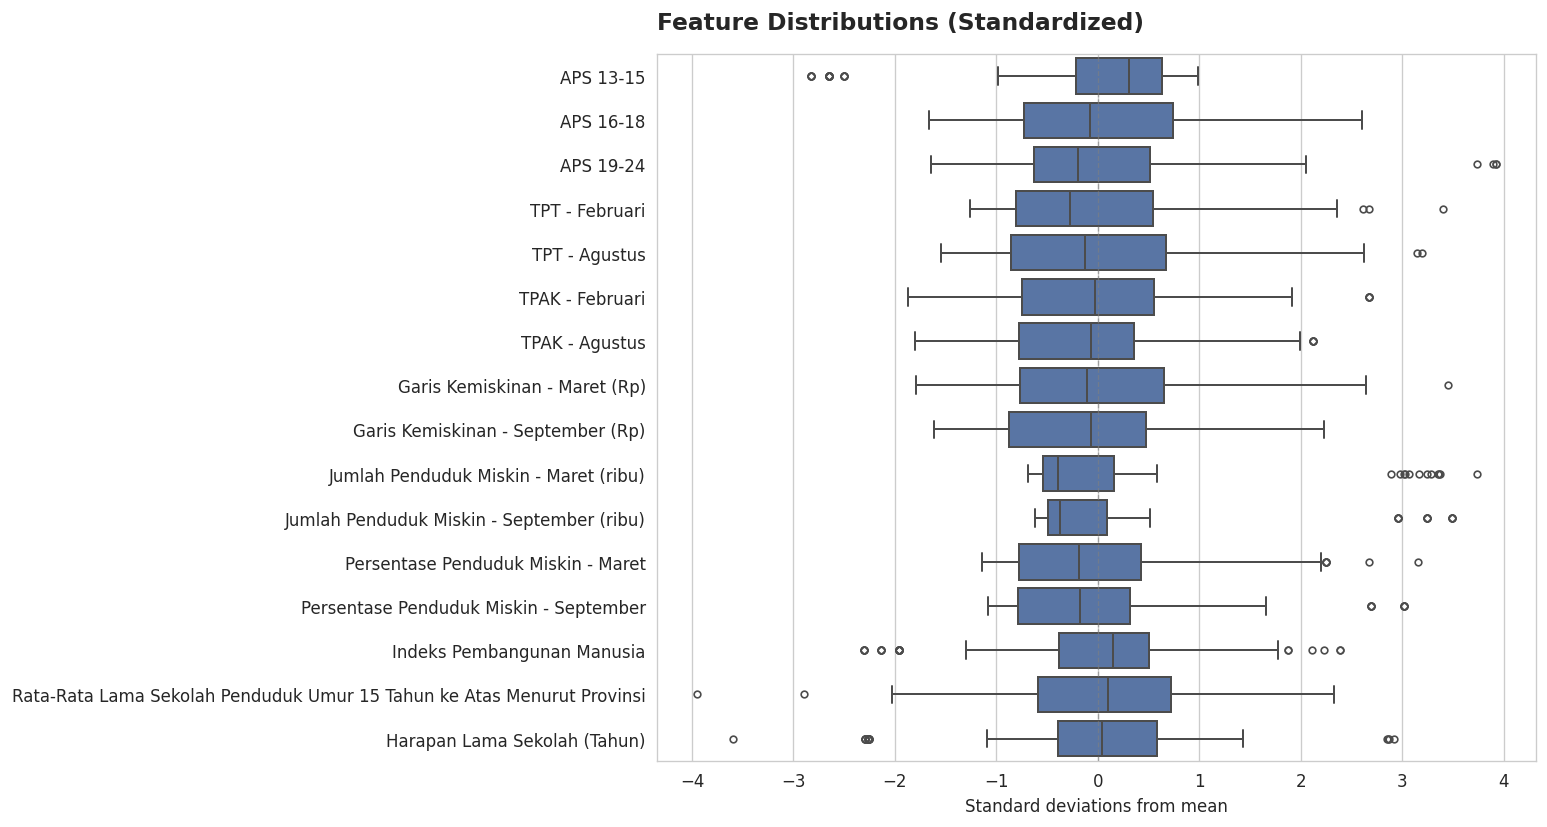

In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'TAHUN' in numeric_cols:
    numeric_cols.remove('TAHUN')

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols]),
    columns=numeric_cols
)
df_long = df_scaled.melt(var_name='Feature', value_name='Z-score')

fig_box = px.box(df_long, x='Z-score', y='Feature', orientation='h', color_discrete_sequence=["#4C72B0"])
fig_box.update_layout(title="Feature Distributions (Standardized)", width=1000, height=700)
# Save as png per standard if needed, or json
fig_box.show()

# Preprocessing

In [ ]:
df['TPT'] = (df['TPT - Februari'] + df['TPT - Agustus']) / 2
df['TPAK'] = (df['TPAK - Februari'] + df['TPAK - Agustus']) / 2
df['Persentase_Miskin'] = (df['Persentase Penduduk Miskin - Maret']
                           + df['Persentase Penduduk Miskin - September']) / 2
df['Garis_Kemiskinan'] = (df['Garis Kemiskinan - Maret (Rp)']
                          + df['Garis Kemiskinan - September (Rp)']) / 2

selected_cols = [
    'APS 13-15', 'APS 16-18', 'APS 19-24',
    'TPT', 'TPAK',
    'Persentase_Miskin',
    'Garis_Kemiskinan',
    'Indeks Pembangunan Manusia',
    'Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi',
    'Harapan Lama Sekolah (Tahun)'
]

X_scaled = pd.DataFrame(
    scaler.fit_transform(df[selected_cols]),
    columns=selected_cols
)
X_scaled.head()

,APS 13-15,APS 16-18,APS 19-24,TPT,TPAK,Persentase_Miskin,Garis_Kemiskinan,Indeks Pembangunan Manusia,Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi,Harapan Lama Sekolah (Tahun)
0,0.510104,0.642165,-0.092633,0.848414,-0.072116,-0.475816,-0.264693,0.333733,0.746744,0.155518
1,0.439411,1.491650,1.438823,1.123419,-0.368702,-0.796553,0.201520,0.486211,0.334321,1.086671
2,0.248933,0.508697,0.192060,-0.109252,-1.033508,-0.686034,0.137132,0.344322,0.393239,0.166874
3,0.392282,-0.325086,-0.568759,0.042810,-0.577318,-0.541509,-0.305686,0.075369,-0.087921,-0.105659
4,0.089874,-0.477397,-1.440838,0.139870,-0.043211,0.076779,-0.911999,-0.091932,-0.333411,-0.673435


# Feature Reduction

## PCA

In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
for i, (e, c) in enumerate(zip(explained, cumulative), 1):
    print(f"PC{i}: {e:.3f} ({c:.3f} cumulative)")

PC1: 0.515 (0.515 cumulative)
PC2: 0.185 (0.700 cumulative)
PC3: 0.114 (0.814 cumulative)
PC4: 0.063 (0.877 cumulative)
PC5: 0.039 (0.916 cumulative)
PC6: 0.030 (0.946 cumulative)
PC7: 0.022 (0.968 cumulative)
PC8: 0.012 (0.981 cumulative)
PC9: 0.011 (0.992 cumulative)
PC10: 0.008 (1.000 cumulative)


Elbow detected at PC3


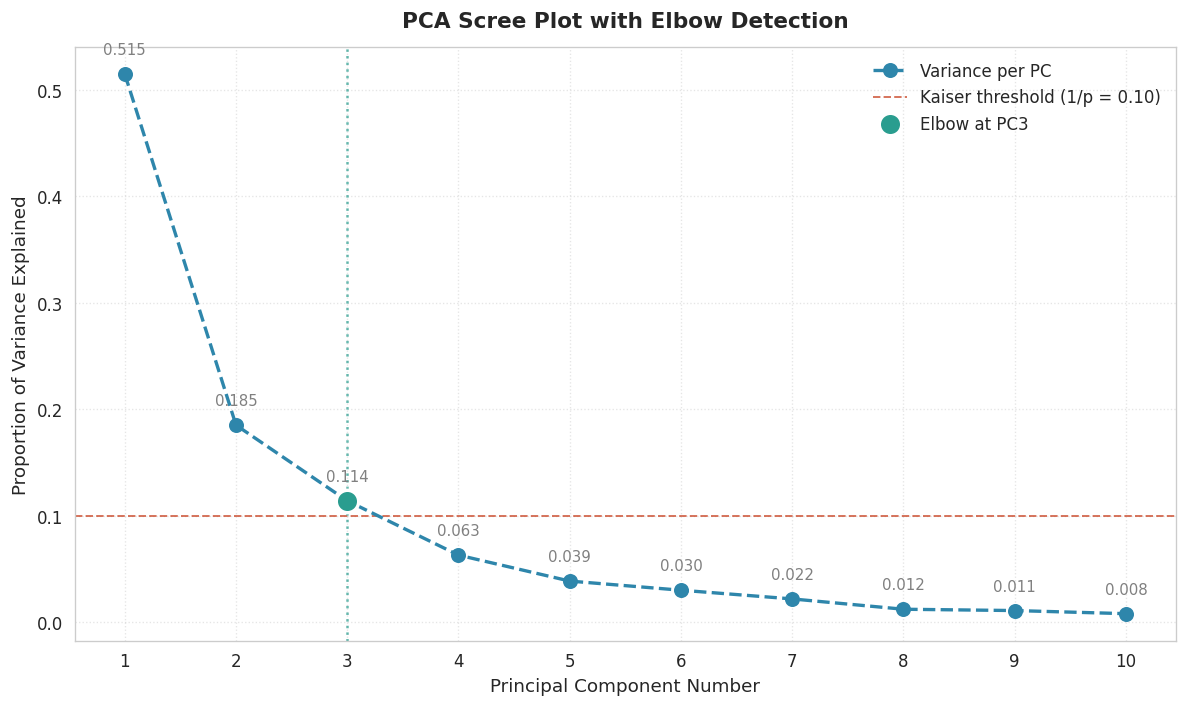

In [ ]:
variance_ratio = pca_full.explained_variance_ratio_
x = np.arange(1, len(variance_ratio) + 1)

kl = KneeLocator(
    x, variance_ratio,
    curve='convex',
    direction='decreasing'
)
elbow = kl.knee
print(f"Elbow detected at PC{elbow}")

n_features = len(variance_ratio)

fig_scree = go.Figure()
fig_scree.add_trace(go.Scatter(x=x, y=variance_ratio, mode='lines+markers', name='Variance per PC', line=dict(color='#2E86AB', dash='dash')))
fig_scree.add_hline(y=1/n_features, line_dash='dash', line_color='#C73E1D', annotation_text=f'Kaiser threshold (1/p = {1/n_features:.2f})')
fig_scree.add_vline(x=elbow, line_dash='dot', line_color='#2A9D8F')
fig_scree.add_trace(go.Scatter(x=[elbow], y=[variance_ratio[elbow-1]], mode='markers', marker=dict(size=15, color='#2A9D8F', line=dict(width=2, color='white')), name=f'Elbow at PC{elbow}'))

fig_scree.update_layout(title='PCA Scree Plot with Elbow Detection', xaxis_title='Principal Component Number', yaxis_title='Proportion of Variance Explained', width=900, height=600)
fig_scree.write_json('cluster_output/plot_pca_scree.json')
fig_scree.show()

In [ ]:
n_pcs = 3

pca = PCA(n_components=n_pcs, random_state=42)
X_pca = pca.fit_transform(X_scaled)

X_pca = pd.DataFrame(
    pca.fit_transform(X_scaled),
    columns=[f"PC{i+1}" for i in range(n_pcs)]
)

X_pca.head()

,PC1,PC2,PC3
0,1.253462,-0.296711,-0.057042
1,2.326697,0.822735,0.413930
2,1.163205,-0.234342,-0.061097
3,0.241469,-0.805655,-0.639760
4,-0.824256,-1.102193,-0.972461


## UMAP

In [ ]:
scores = {}
for n in [2, 3, 5, 10, 15, 20]:
    reducer = umap.UMAP(n_components=n, random_state=42)
    X_embedded = reducer.fit_transform(X_scaled)

    gmm = GaussianMixture(n_components=4, random_state=42)
    labels = gmm.fit_predict(X_embedded)

    scores[n] = silhouette_score(X_embedded, labels)
    print(f"n_components={n}: silhouette={scores[n]:.3f}")

n_components=2: silhouette=0.408
n_components=3: silhouette=0.492
n_components=5: silhouette=0.476
n_components=10: silhouette=0.468
n_components=15: silhouette=0.538
n_components=20: silhouette=0.504


In [ ]:
for n in [2, 3, 5, 10]:
    vals = []
    for seed in range(5):
        reducer = umap.UMAP(n_components=n, random_state=seed)
        X_embedded = reducer.fit_transform(X_scaled)
        gmm = GaussianMixture(n_components=4, random_state=seed)
        labels = gmm.fit_predict(X_embedded)
        vals.append(silhouette_score(X_embedded, labels))
    print(f"n_components={n}: mean={np.mean(vals):.3f}, std={np.std(vals):.3f}")

n_components=2: mean=0.480, std=0.072
n_components=3: mean=0.507, std=0.029
n_components=5: mean=0.519, std=0.021
n_components=10: mean=0.541, std=0.030


In [ ]:
reducer = umap.UMAP(n_components=3, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

X_umap = pd.DataFrame(
    X_umap,
    columns=[f"UMAP{i+1}" for i in range(n_pcs)]
)

X_umap.head()

,UMAP1,UMAP2,UMAP3
0,-0.658197,9.327487,6.280542
1,-1.031898,6.815504,6.046951
2,-0.500001,9.974407,6.785886
3,-0.336323,11.765414,6.676044
4,-0.755115,13.194250,5.617152


# GMM

In [ ]:
n_components_range = range(2, 11)

silhouette_scores_pca = []
davies_bouldin_scores_pca = []
calinski_harabasz_scores_pca = []

silhouette_scores_umap = []
davies_bouldin_scores_umap = []
calinski_harabasz_scores_umap = []

for n_components in n_components_range:
    # GMM for X_pca
    gmm_pca = GaussianMixture(n_components=n_components, random_state=42)
    labels_pca = gmm_pca.fit_predict(X_pca)

    if len(np.unique(labels_pca)) > 1:
        sil_pca = silhouette_score(X_pca, labels_pca)
        db_pca = davies_bouldin_score(X_pca, labels_pca)
        ch_pca = calinski_harabasz_score(X_pca, labels_pca)
    else:
        sil_pca, db_pca, ch_pca = -1, np.inf, 0 # Assign values for single cluster case

    sil_pca = silhouette_score(X_pca, labels_pca)
    db_pca = davies_bouldin_score(X_pca, labels_pca)
    ch_pca = calinski_harabasz_score(X_pca, labels_pca)

    silhouette_scores_pca.append(sil_pca)
    davies_bouldin_scores_pca.append(db_pca)
    calinski_harabasz_scores_pca.append(ch_pca)

    # GMM for X_umap
    gmm_umap = GaussianMixture(n_components=n_components, random_state=42)
    labels_umap = gmm_umap.fit_predict(X_umap)

    if len(np.unique(labels_umap)) > 1:
        sil_umap = silhouette_score(X_umap, labels_umap)
        db_umap = davies_bouldin_score(X_umap, labels_umap)
        ch_umap = calinski_harabasz_score(X_umap, labels_umap)
    else:
        sil_umap, db_umap, ch_umap = -1, np.inf, 0

    silhouette_scores_umap.append(sil_umap)
    davies_bouldin_scores_umap.append(db_umap)
    calinski_harabasz_scores_umap.append(ch_umap)

    print(f"\n-- Number of Components: {n_components} --")
    print(f"X_pca: Silhouette Score = {sil_pca:.3f}, Davies-Bouldin Score = {db_pca:.3f}, Calinski-Harabasz Score = {ch_pca:.3f}")
    print(f"X_umap: Silhouette Score = {sil_umap:.3f}, Davies-Bouldin Score = {db_umap:.3f}, Calinski-Harabasz Score = {ch_umap:.3f}")

optimal_n_components_pca = n_components_range[np.argmax(silhouette_scores_pca)]
gmm_pca = GaussianMixture(n_components=optimal_n_components_pca, random_state=42)
labels_pca = gmm_pca.fit_predict(X_pca)
print(f"\nOptimal number of components for X_pca: {optimal_n_components_pca}")
print(f"GMM for X_pca with {optimal_n_components_pca} components fitted, labels stored in `labels_pca`.")

optimal_n_components_umap = n_components_range[np.argmax(silhouette_scores_umap)]
gmm_umap = GaussianMixture(n_components=optimal_n_components_umap, random_state=42)
labels_umap = gmm_umap.fit_predict(X_umap)
print(f"Optimal number of components for X_umap: {optimal_n_components_umap}")
print(f"GMM for X_umap with {optimal_n_components_umap} components fitted, labels stored in `labels_umap`.")


-- Number of Components: 2 --
X_pca: Silhouette Score = 0.580, Davies-Bouldin Score = 0.452, Calinski-Harabasz Score = 117.912
X_umap: Silhouette Score = 0.749, Davies-Bouldin Score = 0.219, Calinski-Harabasz Score = 282.478

-- Number of Components: 3 --
X_pca: Silhouette Score = 0.344, Davies-Bouldin Score = 1.128, Calinski-Harabasz Score = 91.720
X_umap: Silhouette Score = 0.567, Davies-Bouldin Score = 0.607, Calinski-Harabasz Score = 382.787

-- Number of Components: 4 --
X_pca: Silhouette Score = 0.365, Davies-Bouldin Score = 0.939, Calinski-Harabasz Score = 111.716
X_umap: Silhouette Score = 0.492, Davies-Bouldin Score = 0.642, Calinski-Harabasz Score = 336.585

-- Number of Components: 5 --
X_pca: Silhouette Score = 0.310, Davies-Bouldin Score = 1.160, Calinski-Harabasz Score = 94.080
X_umap: Silhouette Score = 0.568, Davies-Bouldin Score = 0.538, Calinski-Harabasz Score = 575.032

-- Number of Components: 6 --
X_pca: Silhouette Score = 0.351, Davies-Bouldin Score = 1.190, Cali

## Visualization

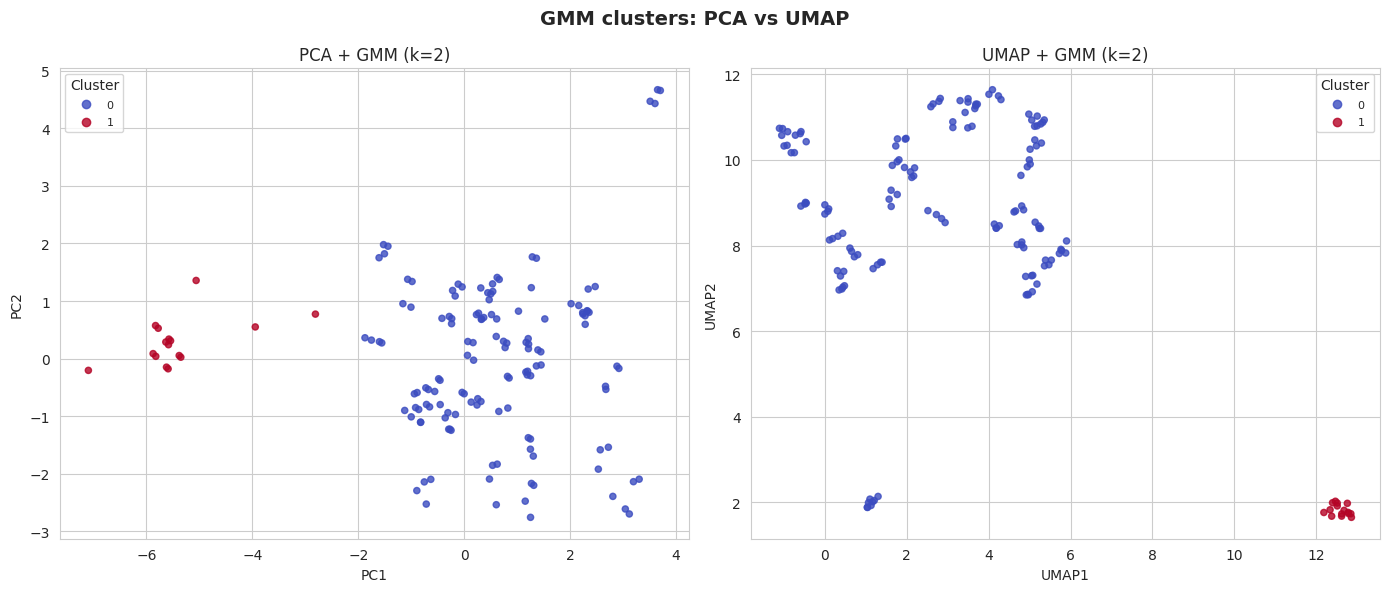

In [ ]:
reducer_2d = umap.UMAP(n_components=2, random_state=42)
X_umap_plot = reducer_2d.fit_transform(X_scaled)
X_pca_arr = np.asarray(X_pca)

fig_2d = make_subplots(rows=1, cols=2, subplot_titles=(f"PCA + GMM (k={len(np.unique(labels_pca))})", f"UMAP + GMM (k={len(np.unique(labels_umap))})"))

fig_2d.add_trace(go.Scatter(x=X_pca_arr[:, 0], y=X_pca_arr[:, 1], mode='markers', marker=dict(color=labels_pca, colorscale='coolwarm', size=8, opacity=0.8), showlegend=False), row=1, col=1)
fig_2d.add_trace(go.Scatter(x=X_umap_plot[:, 0], y=X_umap_plot[:, 1], mode='markers', marker=dict(color=labels_umap, colorscale='coolwarm', size=8, opacity=0.8), showlegend=False), row=1, col=2)

fig_2d.update_xaxes(title_text="PC1", row=1, col=1)
fig_2d.update_yaxes(title_text="PC2", row=1, col=1)
fig_2d.update_xaxes(title_text="UMAP1", row=1, col=2)
fig_2d.update_yaxes(title_text="UMAP2", row=1, col=2)

fig_2d.update_layout(title_text="GMM clusters: PCA vs UMAP", height=600, width=1200)
fig_2d.write_json('cluster_output/plot_gmm_comparison_2d.json')
fig_2d.show()

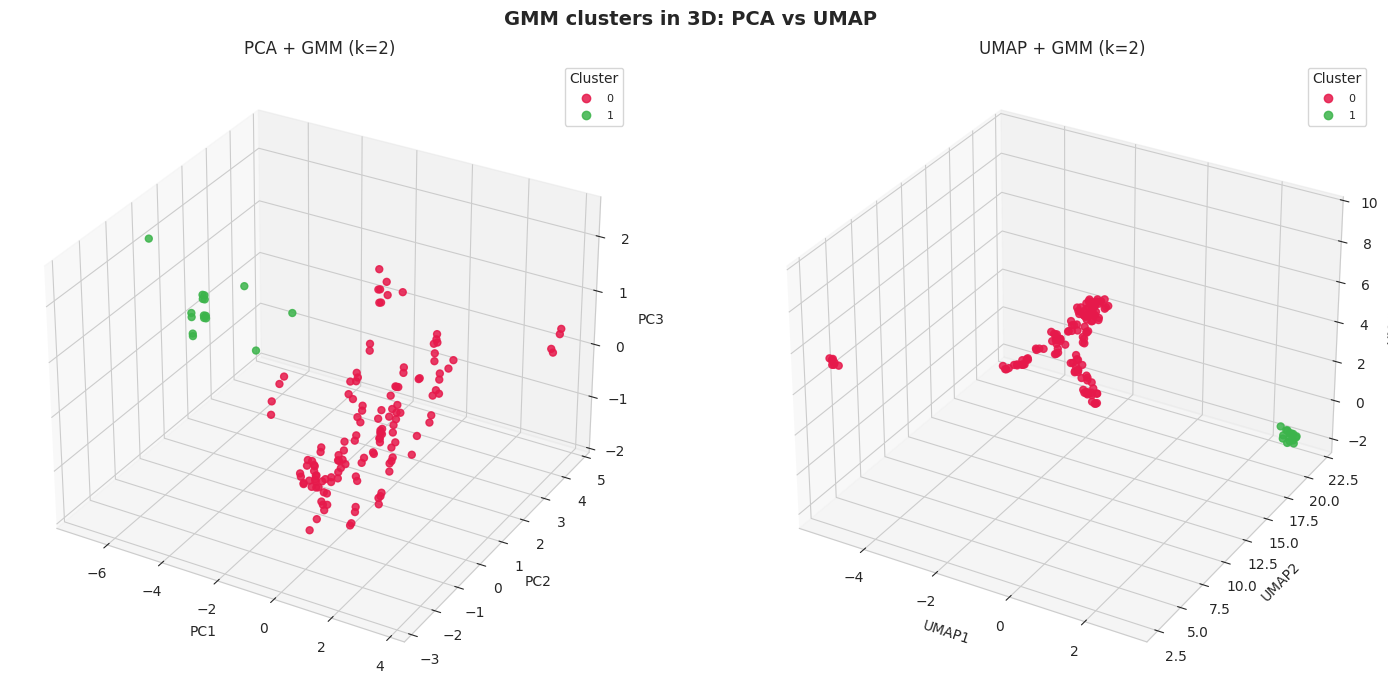

In [ ]:
X_pca_arr  = np.asarray(X_pca)
X_umap_arr = np.asarray(X_umap)

fig_3d = make_subplots(rows=1, cols=2, specs=[[{'type': 'scene'}, {'type': 'scene'}]], subplot_titles=(f"PCA + GMM (k={len(np.unique(labels_pca))})", f"UMAP + GMM (k={len(np.unique(labels_umap))})"))

fig_3d.add_trace(go.Scatter3d(x=X_pca_arr[:, 0], y=X_pca_arr[:, 1], z=X_pca_arr[:, 2], mode='markers', marker=dict(color=labels_pca, colorscale='rainbow', size=5, opacity=0.8), showlegend=False), row=1, col=1)
fig_3d.add_trace(go.Scatter3d(x=X_umap_arr[:, 0], y=X_umap_arr[:, 1], z=X_umap_arr[:, 2], mode='markers', marker=dict(color=labels_umap, colorscale='rainbow', size=5, opacity=0.8), showlegend=False), row=1, col=2)

fig_3d.update_layout(
    title_text="GMM clusters in 3D: PCA vs UMAP",
    height=800, width=1400,
    scene1=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
    scene2=dict(xaxis_title='UMAP1', yaxis_title='UMAP2', zaxis_title='UMAP3')
)
fig_3d.write_json('cluster_output/plot_gmm_comparison_3d.json')
fig_3d.show()